## 1. Data Loading and Preprocessing
We load the MNIST dataset, normalize the pixel values to the [0, 1] range, and prepare versions for both Dense and CNN architectures.

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load dataset - Fixed method name from load_dataset to load_data
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# Prepare data for Dense Networks (Flattened)
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

# Prepare data for CNNs (Reshaped with channel dimension)
x_train_cnn = x_train.reshape((-1, 28, 28, 1))
x_test_cnn = x_test.reshape((-1, 28, 28, 1))

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train_raw, 10)
y_test = tf.keras.utils.to_categorical(y_test_raw, 10)

print(f"Training shape: {x_train_raw.shape}")
print(f"Test shape: {x_test_raw.shape}")

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 2. Model Architectures


In [15]:
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_dropout_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

## 3. Training Configuration
We use the Adam optimizer and Categorical Cross-entropy as specified.

In [ ]:
def compile_and_train(model, train_data, train_labels, epochs=20):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

    history = model.fit(
        train_data, train_labels,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    return history

print("Training Model 1: Baseline Dense...")
model1 = build_baseline_model()
hist1 = compile_and_train(model1, x_train_flat, y_train)

print("\nTraining Model 2: Dense with Dropout...")
model2 = build_dropout_model()
hist2 = compile_and_train(model2, x_train_flat, y_train)

print("\nTraining Model 3: CNN...")
model3 = build_cnn_model()
hist3 = compile_and_train(model3, x_train_cnn, y_train)

Training Model 1: Baseline Dense...
Epoch 1/20


W0000 00:00:1778385192.142598    8116 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8947 - loss: 0.3728 - val_accuracy: 0.9449 - val_loss: 0.1916
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9548 - loss: 0.1527 - val_accuracy: 0.9611 - val_loss: 0.1306
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9680 - loss: 0.1078 - val_accuracy: 0.9683 - val_loss: 0.1108
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0806 - val_accuracy: 0.9693 - val_loss: 0.1029
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0632 - val_accuracy: 0.9730 - val_loss: 0.0938
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.0491 - val_accuracy: 0.9729 - val_loss: 0.0925
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0399 - val_accuracy: 0.9732 - val_loss: 0.0942
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9909 - loss: 0.0315 - val_accuracy: 0.9720 - val_

W0000 00:00:1778385203.687701    8116 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8499 - loss: 0.5031 - val_accuracy: 0.9480 - val_loss: 0.1829
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9350 - loss: 0.2201 - val_accuracy: 0.9619 - val_loss: 0.1340
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9516 - loss: 0.1666 - val_accuracy: 0.9671 - val_loss: 0.1129
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9604 - loss: 0.1341 - val_accuracy: 0.9708 - val_loss: 0.0995
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9646 - loss: 0.1153 - val_accuracy: 0.9723 - val_loss: 0.0906
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.1026 - val_accuracy: 0.9729 - val_loss: 0.0869
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.0891 - val_accuracy: 0.9745 - val_loss: 0.0864
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0794 - val_accuracy: 0.9757 - val_

## 4. Evaluation and Analysis


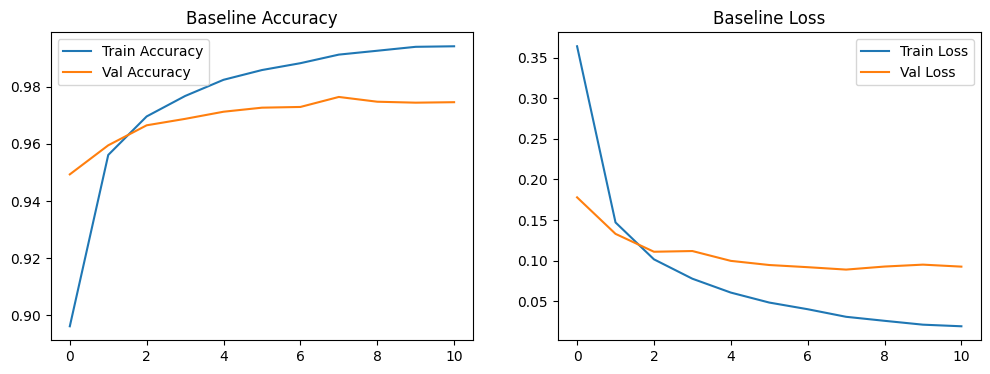

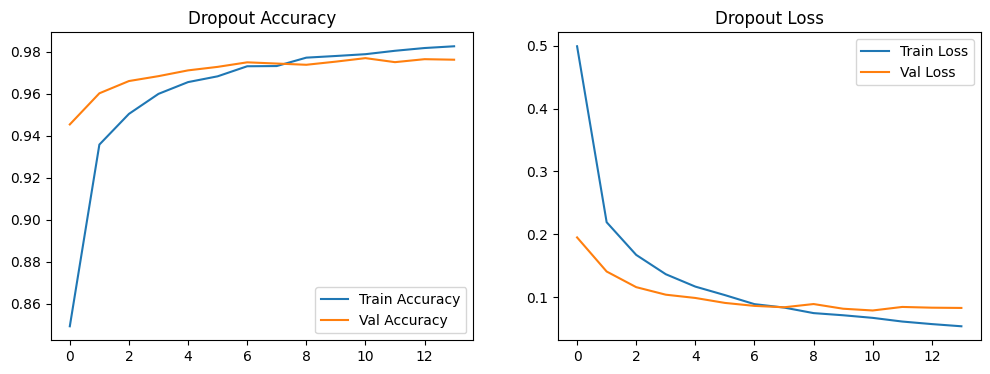

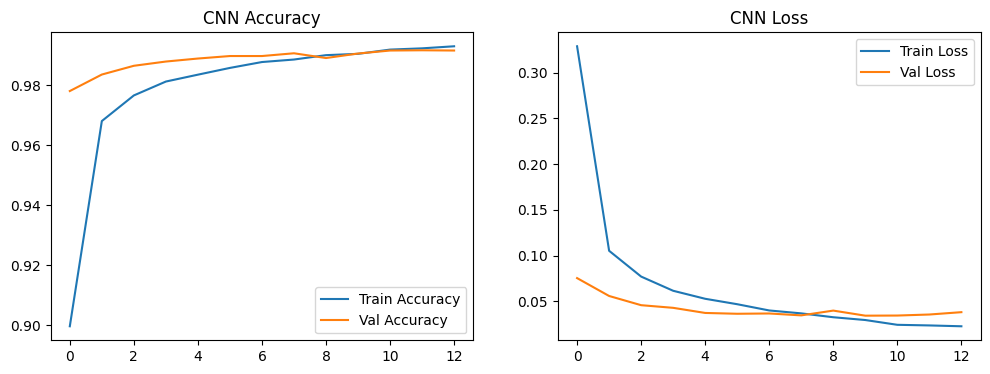

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


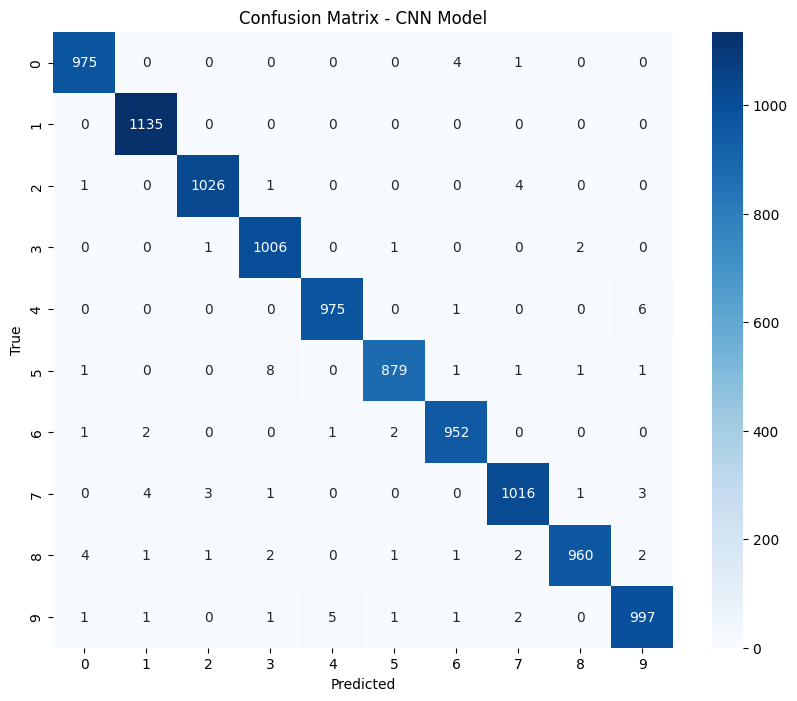

In [ ]:
def plot_results(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

plot_results(hist1, "Baseline")
plot_results(hist2, "Dropout")
plot_results(hist3, "CNN")

# Evaluate models on test set
test_loss1, acc1 = model1.evaluate(x_test_flat, y_test, verbose=0)
test_loss2, acc2 = model2.evaluate(x_test_flat, y_test, verbose=0)
test_loss3, acc3 = model3.evaluate(x_test_cnn, y_test, verbose=0)

# Confusion Matrix for CNN (Model 3)
y_pred = model3.predict(x_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN Model')
plt.show()

## 5. Model Performance Comparison Table
Summary of test metrics for all three evaluated architectures.

In [ ]:
import pandas as pd
import time

def get_summary(model, history, name, test_data, test_labels):
    test_loss, test_acc = model.evaluate(test_data, test_labels, verbose=0)
    train_acc = history.history['accuracy'][-1]
    params = model.count_params()
    return [name, model.name, train_acc, test_acc, params]

data = [
    ['Model 1', 'Baseline Dense', hist1.history['accuracy'][-1], acc1, model1.count_params()],
    ['Model 2', 'Dense with Dropout', hist2.history['accuracy'][-1], acc2, model2.count_params()],
    ['Model 3', 'CNN', hist3.history['accuracy'][-1], acc3, model3.count_params()]
]

comparison_df = pd.DataFrame(data, columns=['Models', 'Architecture', 'Training Accuracy', 'Test Accuracy', 'Parameters'])
display(comparison_df)

,Models,Architecture,Training Accuracy,Test Accuracy,Parameters
0,Model 1,Baseline Dense,0.994146,0.9770,109386
1,Model 2,Dense with Dropout,0.982562,0.9793,109386
2,Model 3,CNN,0.992917,0.9921,225034


In [ ]:
print(f"Baseline Model Final Validation Accuracy: {hist1.history['val_accuracy'][-1]:.4f}")
print(f"Dropout Model Final Validation Accuracy: {hist2.history['val_accuracy'][-1]:.4f}")
print(f"CNN Model Final Validation Accuracy: {hist3.history['val_accuracy'][-1]:.4f}")

Baseline Model Final Validation Accuracy: 0.9746
Dropout Model Final Validation Accuracy: 0.9762
CNN Model Final Validation Accuracy: 0.9915
